In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from category_encoders import TargetEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
import lightgbm as lgb

In [7]:
df_raw = pd.read_csv("../data/raw/train.csv")
df_raw = df_raw.drop_duplicates()

X = df_raw.drop("Label", axis=1)
y = df_raw["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
encoder = TargetEncoder(cols=["proto", "service", "state"])
X_train_encoded = encoder.fit_transform(X_train, y_train)
X_test_encoded = encoder.transform(X_test)

smote = SMOTE(sampling_strategy={4: 4000, 6: 4000, 7: 4000, 8: 2000, 9: 2000}, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_encoded, y_train)

model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_resampled, y_train_resampled)

y_pred = model.predict(X_test_encoded)
print("Macro F1 :", round(f1_score(y_test, y_pred, average="macro"), 4))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010492 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6901
[LightGBM] [Info] Number of data points in the train set: 104313, number of used features: 42
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
Macro F1 : 0.5843


In [9]:
scores = f1_score(y_test, y_pred, average=None)
for i, s in enumerate(scores):
    print(f"Label {i} : {round(s, 4)}")

Label 0 : 0.8974
Label 1 : 0.9334
Label 2 : 0.8197
Label 3 : 0.669
Label 4 : 0.3337
Label 5 : 0.7904
Label 6 : 0.1441
Label 7 : 0.1445
Label 8 : 0.6206
Label 9 : 0.4906


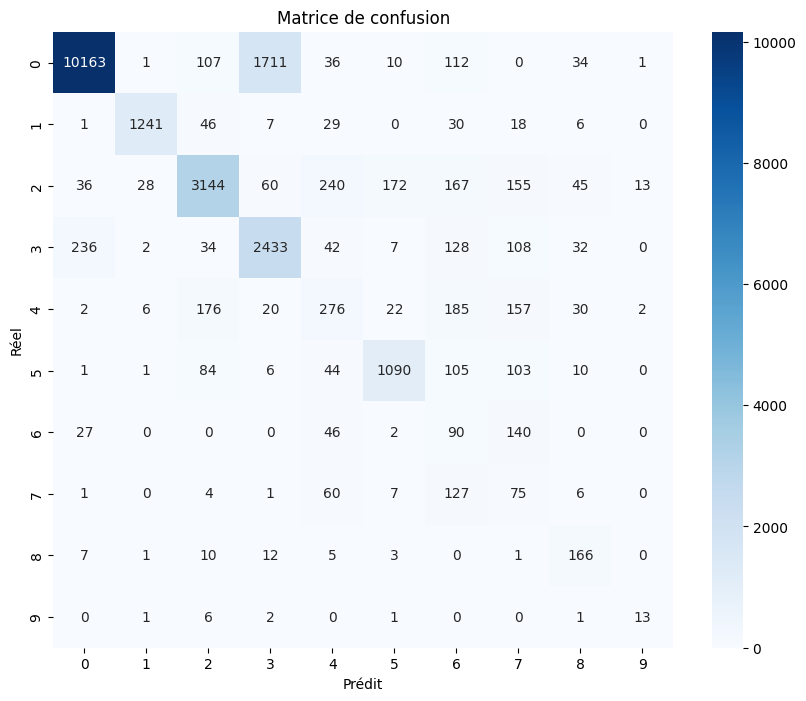

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()